In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Part 1: Prepare the Data

In [6]:
# 1. Read myopia.csv into a Pandas DataFrame.
df = pd.read_csv("myopia.csv", sep=";")

In [5]:
df

,ID,STUDYYEAR,MYOPIC,AGE,GENDER,SPHEQ,AL,ACD,LT,VCD,SPORTHR,READHR,COMPHR,STUDYHR,TVHR,DIOPTERHR,MOMMY,DADMY
0,1,1992,1,6,1,-0.052,21.89,3.690,3.498,14.70,45,8,0,0,10,34,1,1
1,2,1995,0,6,1,0.608,22.38,3.702,3.392,15.29,4,0,1,1,7,12,1,1
2,3,1991,0,6,1,1.179,22.49,3.462,3.514,15.52,14,0,2,0,10,14,0,0
3,4,1990,1,6,1,0.525,22.20,3.862,3.612,14.73,18,11,0,0,4,37,0,1
4,5,1995,0,5,0,0.697,23.29,3.676,3.454,16.16,14,0,0,0,4,4,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
613,614,1995,1,6,0,0.678,22.40,3.663,3.803,14.93,2,0,7,3,14,37,1,0
614,615,1993,0,6,1,0.665,22.50,3.570,3.378,15.56,6,0,1,0,8,10,1,1
615,616,1995,0,6,0,1.834,22.94,3.624,3.424,15.89,8,0,0,0,4,4,1,1
616,617,1991,0,6,1,0.665,21.92,3.688,3.598,14.64,12,2,1,0,15,23,0,0


In [7]:
# 2. Remove the "MYOPIC" column from the dataset.
X = df.drop(columns=["MYOPIC"])

In [8]:
# 3. Standardize your dataset so that columns that contain larger values do not influence the outcome more than columns
# with smaller values.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Part 2: Apply Dimensionality Reduction

In [10]:
# 1. Perform dimensionality reduction with PCA. How did the number of the features change?

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of features after PCA:", X_pca.shape[1])
print(f"PCA preserved {sum(pca.explained_variance_ratio_)*100:.2f}% of variance")
print(f"Number of components used: {pca.n_components_}")

Original number of features: 17
Number of features after PCA: 12
PCA preserved 90.54% of variance
Number of components used: 12


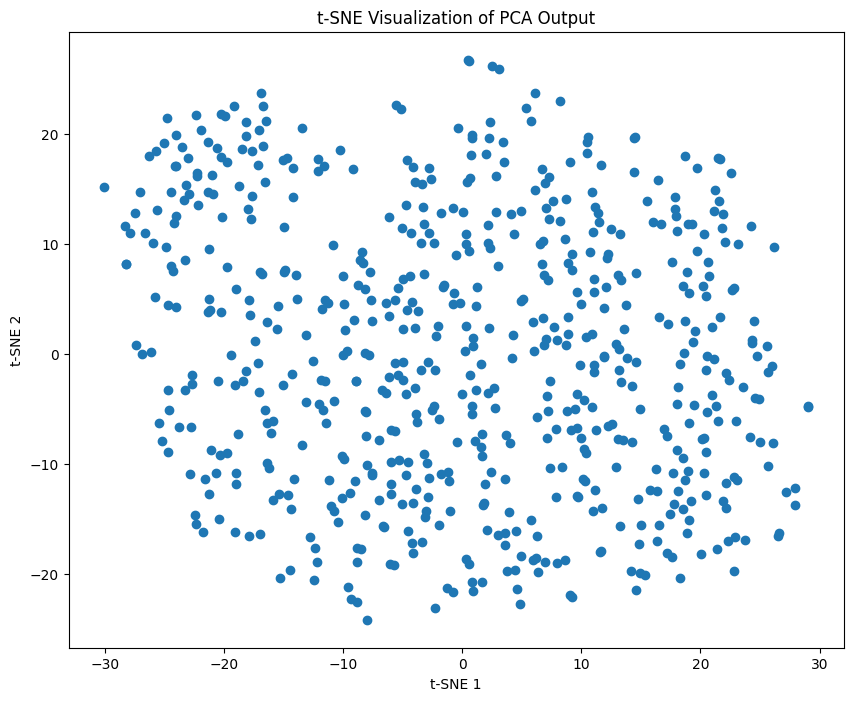

In [15]:
# 2. Further reduce the dataset dimensions with t-SNE and visually inspect the results.
# To do this, run t-SNE on the principal components, which is the output of the PCA transformation.

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(10, 8))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1])
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE Visualization of PCA Output")
plt.show()

 ### Are there distinct clusters?

# Part 3: K-Means Cluster Analysis

### Elbow Plot

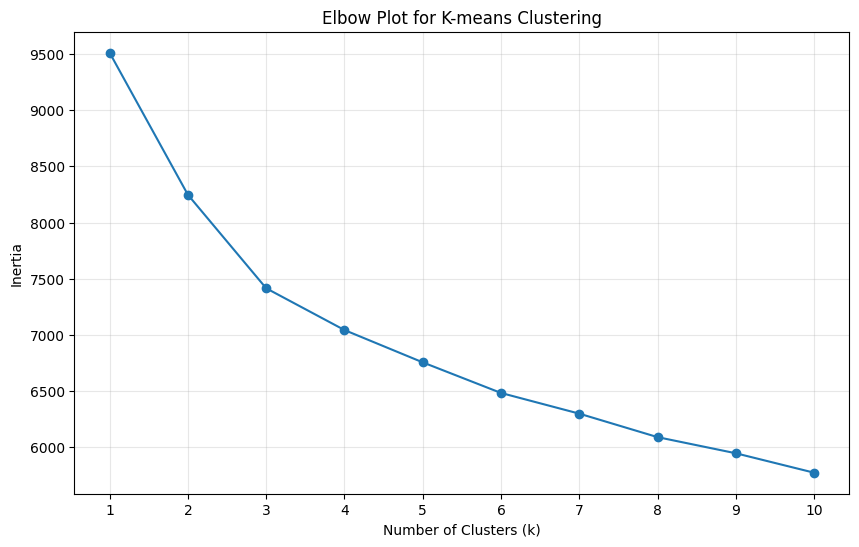

In [16]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for K-means Clustering")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()

# Part 4: Recommendation